## From Scratch

In [1]:
import math
import random

class SimpleLinearRegression:
    def __init__(self):
        self.slope = 0.0      # weight (w)
        self.intercept = 0.0  # bias (b)
    
    def fit(self, X, y):
        """
        Train the model using the normal equation (closed-form solution)
        X: list of input values (features)
        y: list of target values
        """
        n = len(X)
        
        # Calculate means
        x_mean = sum(X) / n
        y_mean = sum(y) / n
        
        # Calculate slope: sum((x - x_mean)(y - y_mean)) / sum((x - x_mean)^2)
        numerator = sum((X[i] - x_mean) * (y[i] - y_mean) for i in range(n))
        denominator = sum((X[i] - x_mean) ** 2 for i in range(n))
        
        self.slope = numerator / denominator
        self.intercept = y_mean - self.slope * x_mean
        
        return self
    
    def predict(self, X):
        """Make predictions for new data"""
        if isinstance(X, (int, float)):
            return self.slope * X + self.intercept
        return [self.slope * x + self.intercept for x in X]
    
    def r_squared(self, X, y):
        """Calculate R-squared score"""
        predictions = self.predict(X)
        y_mean = sum(y) / len(y)
        
        ss_res = sum((y[i] - predictions[i]) ** 2 for i in range(len(y)))
        ss_tot = sum((y[i] - y_mean) ** 2 for i in range(len(y)))
        
        return 1 - (ss_res / ss_tot)

# Example usage
if __name__ == "__main__":
    # Generate sample data: y = 2.5x + 5 + noise
    random.seed(42)
    X = [random.uniform(0, 10) for _ in range(50)]
    y = [2.5 * x + 5 + random.gauss(0, 1.5) for x in X]
    
    # Train model
    model = SimpleLinearRegression()
    model.fit(X, y)
    
    print(f"Learned: y = {model.slope:.4f}x + {model.intercept:.4f}")
    print(f"R² Score: {model.r_squared(X, y):.4f}")
    
    # Make predictions
    new_x = 7.5
    pred = model.predict(new_x)
    print(f"Prediction for x={new_x}: {pred:.4f}")

Learned: y = 2.4304x + 5.5752
R² Score: 0.9626
Prediction for x=7.5: 23.8034


## With Gradient Descent

Epoch    0 | Cost: 84.722873 | w: 1.0676 | b: 0.1674
Epoch  100 | Cost: 1.996381 | w: 3.2486 | b: 0.8547
Epoch  200 | Cost: 1.924355 | w: 3.2081 | b: 1.1194
Epoch  300 | Cost: 1.882104 | w: 3.1771 | b: 1.3221
Epoch  400 | Cost: 1.857319 | w: 3.1533 | b: 1.4774
Epoch  500 | Cost: 1.842781 | w: 3.1352 | b: 1.5963
Epoch  600 | Cost: 1.834252 | w: 3.1212 | b: 1.6874
Epoch  700 | Cost: 1.829249 | w: 3.1105 | b: 1.7571
Epoch  800 | Cost: 1.826314 | w: 3.1024 | b: 1.8105
Epoch  900 | Cost: 1.824593 | w: 3.0961 | b: 1.8515

Final: y = 3.0914x + 1.8825
R² Score: 0.9572


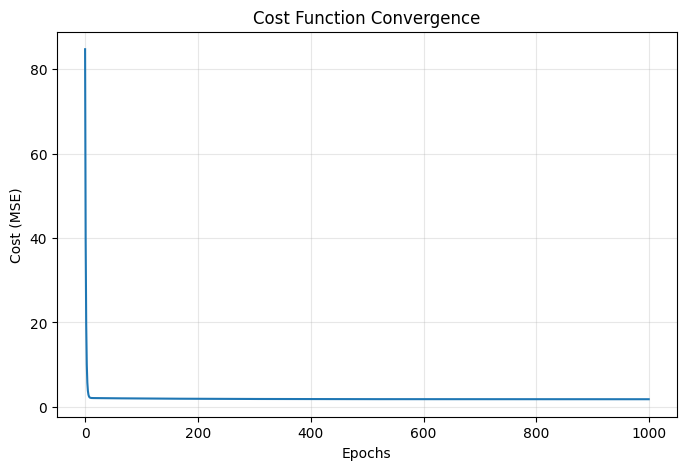

In [2]:
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.slope = 0.0
        self.intercept = 0.0
        self.cost_history = []
    
    def predict(self, X):
        if isinstance(X, (int, float)):
            return self.slope * X + self.intercept
        return [self.slope * x + self.intercept for x in X]
    
    def compute_cost(self, X, y):
        """Mean Squared Error"""
        predictions = self.predict(X)
        n = len(y)
        return sum((predictions[i] - y[i]) ** 2 for i in range(n)) / (2 * n)
    
    def fit(self, X, y):
        n = len(y)
        
        for epoch in range(self.epochs):
            # Forward pass: make predictions
            predictions = self.predict(X)
            
            # Calculate gradients
            # dJ/dw = (1/n) * sum((y_pred - y) * x)
            # dJ/db = (1/n) * sum(y_pred - y)
            gradient_slope = sum((predictions[i] - y[i]) * X[i] for i in range(n)) / n
            gradient_intercept = sum(predictions[i] - y[i] for i in range(n)) / n
            
            # Update parameters (go opposite to gradient)
            self.slope -= self.lr * gradient_slope
            self.intercept -= self.lr * gradient_intercept
            
            # Track cost for monitoring
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)
            
            # Print progress every 100 epochs
            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Cost: {cost:.6f} | w: {self.slope:.4f} | b: {self.intercept:.4f}")
        
        return self
    
    def r_squared(self, X, y):
        predictions = self.predict(X)
        y_mean = sum(y) / len(y)
        ss_res = sum((y[i] - predictions[i]) ** 2 for i in range(len(y)))
        ss_tot = sum((y[i] - y_mean) ** 2 for i in range(len(y)))
        return 1 - (ss_res / ss_tot)
    
    def plot_cost(self):
        """Visualize the cost function decreasing over time"""
        plt.figure(figsize=(8, 5))
        plt.plot(self.cost_history)
        plt.xlabel('Epochs')
        plt.ylabel('Cost (MSE)')
        plt.title('Cost Function Convergence')
        plt.grid(True, alpha=0.3)
        plt.show()

# Example usage
if __name__ == "__main__":
    import random
    random.seed(42)
    
    # Generate data
    X = [random.uniform(0, 10) for _ in range(100)]
    y = [3.0 * x + 2.0 + random.gauss(0, 2.0) for x in X]
    
    # Train with Gradient Descent
    model_gd = LinearRegressionGD(learning_rate=0.01, epochs=1000)
    model_gd.fit(X, y)
    
    print(f"\nFinal: y = {model_gd.slope:.4f}x + {model_gd.intercept:.4f}")
    print(f"R² Score: {model_gd.r_squared(X, y):.4f}")
    
    # Plot convergence
    model_gd.plot_cost()

## Using NumPy

In [3]:
import numpy as np

class LinearRegressionNumpy:
    def __init__(self):
        self.slope = 0.0
        self.intercept = 0.0
    
    def fit(self, X, y):
        """Using vectorized NumPy operations - much faster!"""
        X = np.array(X)
        y = np.array(y)
        
        # Add a column of ones for the intercept term
        X_b = np.c_[np.ones((len(X), 1)), X]
        
        # Normal equation: w = (X^T X)^-1 X^T y
        w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        self.intercept = w[0]
        self.slope = w[1]
        return self
    
    def predict(self, X):
        X = np.array(X)
        return self.slope * X + self.intercept
    
    def score(self, X, y):
        """R² score"""
        X, y = np.array(X), np.array(y)
        predictions = self.predict(X)
        y_mean = np.mean(y)
        ss_res = np.sum((y - predictions) ** 2)
        ss_tot = np.sum((y - y_mean) ** 2)
        return 1 - (ss_res / ss_tot)

# Example
if __name__ == "__main__":
    np.random.seed(42)
    X = np.random.uniform(0, 10, 100)
    y = 3.5 * X + 1.5 + np.random.normal(0, 1.5, 100)
    
    model = LinearRegressionNumpy()
    model.fit(X, y)
    
    print(f"y = {model.slope:.4f}x + {model.intercept:.4f}")
    print(f"R²: {model.score(X, y):.4f}")

y = 3.4310x + 1.8226
R²: 0.9827


##  Using Scikit-Learn

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Generate data
np.random.seed(42)
X = np.random.uniform(0, 10, (100, 1))  # Note: 2D array required by sklearn
y = 3.0 * X.ravel() + 2.0 + np.random.normal(0, 1.5, 100)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

# Predict on new data
new_house = np.array([[7.5]])
prediction = model.predict(new_house)
print(f"Prediction for x=7.5: {prediction[0]:.4f}")

Coefficient (slope): 2.9398
Intercept: 2.2144
R² Score: 0.9825
MSE: 1.4708
Prediction for x=7.5: 24.2628


## Visualizing the Results

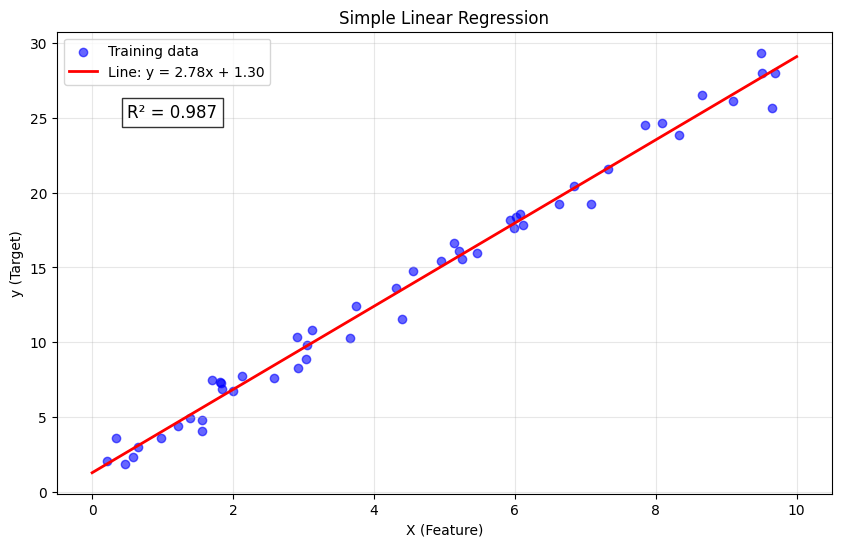

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Generate data
np.random.seed(42)
X = np.random.uniform(0, 10, (50, 1))
y = 2.8 * X.ravel() + 1.2 + np.random.normal(0, 1.0, 50)

# Train model
model = LinearRegression()
model.fit(X, y)

# Make predictions for plotting
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(X_line)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Training data')
plt.plot(X_line, y_line, color='red', linewidth=2, label=f'Line: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Simple Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Add some annotations
plt.text(0.5, 25, f'R² = {model.score(X, y):.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()